In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC


In [3]:
from DataVisualization import PlotBinaryClassData

In [4]:
numSamples0 = 250
numSamples1 = 250
numGridsPoints = 250 

In [23]:
numSamples = numSamples0 + numSamples1
mX = np.random.rand(numSamples, 2) - 0.5 # unit destribution of column from 0 to 1 shifted bt 0.5
mX[numSamples0:, 0] += 2 # the buttom half of first row is increased by 2
vY = np.ones((numSamples, ), dtype=np.intp) # intp is numpy integer type that matches the OS typr 64 or 32 bit
vY[:numSamples0] = -1 # first half of vY is -1, rest is 1

# One sample defined manually
mX[0, 0] = 0.75
vY[0] = 1

print(f"The shape of the matrix mX: {mX.shape}")
print(f"The shape of class vector vY: {vY.shape}")


The shape of the matrix mX: (500, 2)
The shape of class vector vY: (500,)


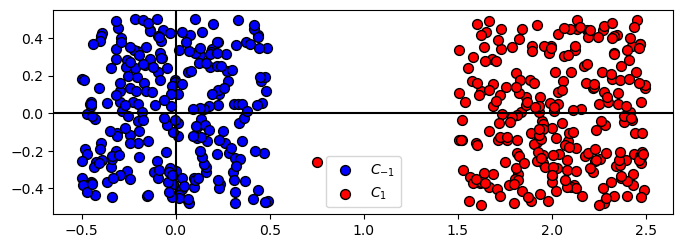

In [37]:
hA = PlotBinaryClassData(mX, vY)

In [191]:
clf = SVC(C=5, kernel='linear')
clf.fit(mX, vY)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [192]:
print(f"Shape of the SVC.coef_: {clf.coef_.shape}")
print(f"Weight_coefficients_as_is: {clf.coef_}")

print("")
print(f"Shape of the SVC.intercept_: {clf.intercept_.shape}")
print(f"Value of the SVC.intercept_: {clf.intercept_}")


Shape of the SVC.coef_: (1, 2)
Weight_coefficients_as_is: [[1.96441578 0.01406301]]

Shape of the SVC.intercept_: (1,)
Value of the SVC.intercept_: [-1.9553317]


In [193]:
vW = clf.coef_[0]
b = clf.intercept_

In [194]:
vX = np.linspace(0, 2, 10)
vL = (-vW[0] / vW[1]) * vX - b / vW[1] # separation line, w1 * x1 + w2 * x2 + b = 0
vL_plus = (-vW[0] / vW[1]) * vX + (1 - b) / vW[1]
vL_minus = (-vW[0] / vW[1]) * vX - (1 + b) / vW[1]

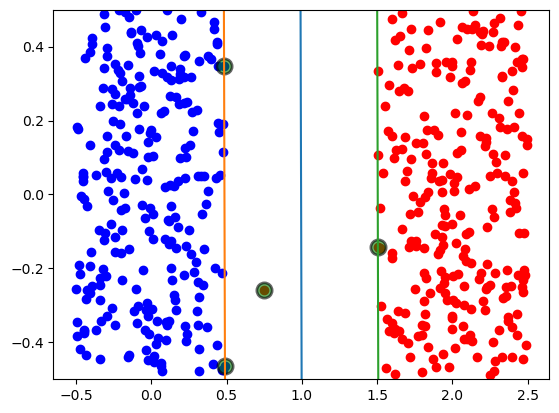

In [ ]:
plt.scatter(mX[vY == -1][:, 0], mX[vY == -1][:, 1], marker='o', color='blue')
plt.scatter(mX[vY == 1][:, 0], mX[vY == 1][:, 1], marker='o', color='red' )
plt.ylim(-0.5, 0.5)
 

In [161]:
clf.support_vectors_

array([[ 0.48395472,  0.34867764],
       [ 0.48957957, -0.46478414],
       [ 0.75      , -0.2593008 ],
       [ 1.50538484, -0.1422276 ]])

In [141]:
vY.shape

(500,)

In [143]:
1 - vY.reshape(500,1) * (mX @ clf.coef_.T - clf.intercept_)

array([[ -9.42707502],
       [  9.34434824],
       [  5.582327  ],
       [  4.6699592 ],
       [  7.19548664],
       [  3.30410435],
       [  6.45277783],
       [  4.13516407],
       [  5.69048768],
       [  6.72508469],
       [  6.94554213],
       [  3.87388321],
       [  7.18279983],
       [  9.17491317],
       [  5.00263183],
       [  6.92500389],
       [  5.68415119],
       [  5.2027089 ],
       [  2.71460339],
       [  6.59501726],
       [  2.75162217],
       [  7.86492092],
       [  7.69925827],
       [  2.26302453],
       [  4.10897852],
       [  5.94443648],
       [  8.09457182],
       [  3.32644146],
       [  6.71931718],
       [  3.43896152],
       [  5.52338488],
       [  2.7110139 ],
       [  2.02011707],
       [  2.12934331],
       [  1.90634728],
       [  3.7058977 ],
       [  7.50808023],
       [  6.19016147],
       [  5.71518968],
       [  7.42256864],
       [  8.26786309],
       [  7.79067717],
       [  4.87808988],
       [  5

In [153]:
def ksi(mX, vY, o_clf):
    v_expression = 1 - vY.reshape(500, 1) * (mX @ o_clf.coef_.T - o_clf.intercept_)
    return np.maximum(0, v_expression)

In [154]:
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]

w1 = []
w2 = []
b = []
loss = []

for C in C_values:
    clf = SVC(C=C, kernel='linear').fit(mX, vY)
    w1.append(clf.coef_[0][0])
    w2.append(clf.coef_[0][1])
    b.append(clf.intercept_)
    loss.append(0.5 * (np.linalg.norm(clf.coef_[0], 2)) ** 2 + C * np.sum(ksi(mX, vY,clf)))

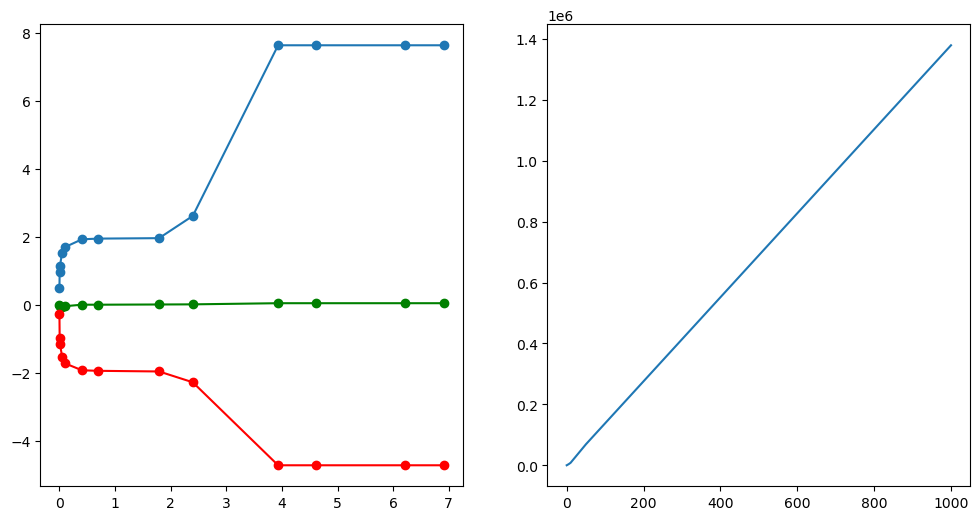

In [155]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].plot(np.log1p(C_values), w1, marker='o')
ax[0].plot(np.log1p(C_values), w2, marker='o', color='green')
ax[0].plot(np.log1p(C_values), b, marker='o', color='red')

ax[1].plot(C_values, loss)
plt.show()
